### KHỞI TẠO MÔ HÌNH

In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")
import torch
import ipynbname
from pathlib import Path
import yaml
import pickle
import pandas as pd
import numpy as np
import importlib
import random
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import json

try:
    notebook_path = ipynbname.path()
    project_root = notebook_path.parents[1]  
    os.chdir(project_root)
    print("Working dir set to:", project_root)
except Exception as e:
    print("Không xác định được vị trí notebook:", e)
    project_root = Path.cwd()
    print("Fallback to cwd:", project_root)
    
import inference

project_root = Path(os.getcwd()).resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
else:
    sys.path.remove(str(project_root))
    sys.path.insert(0, str(project_root))

print("sys.path[0]:", sys.path[0])

print("Using inference file:", getattr(inference, "__file__", "UNKNOWN"))

inference = importlib.reload(inference)

EcommerceRecommendationSystem = inference.EcommerceRecommendationSystem
print("Reloaded EcommerceRecommendationSystem from:", inference.__file__)


Working dir set to: e:\DACNTT_nopbai\source_code
sys.path[0]: E:\DACNTT_nopbai\source_code
Using inference file: e:\DACNTT_nopbai\source_code\inference.py
Reloaded EcommerceRecommendationSystem from: E:\DACNTT_nopbai\source_code\inference.py


In [2]:
config_path = "config/config.yaml"

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

rec_sys = EcommerceRecommendationSystem(
    config_path=str(project_root / 'config/config.yaml'),
    model_dir=str(project_root / 'models/saved_models')
)
device = torch.device(config["training"]["device"])
print("✓ System loaded successfully!")
print(f"Total users: {len(rec_sys.mappings['user2id'])}")
print(f"Total items: {len(rec_sys.mappings['item2id'])}")

✓ System loaded successfully!
Total users: 73283
Total items: 4167


In [4]:
# config_path = "config/config.yaml"

# with open(config_path, "r") as f:
#     config = yaml.safe_load(f)

processed_dir = Path(config["data"]["processed_path"])

# reviews đã tiền xử lý (giống train.py lưu)
reviews_df = pd.read_pickle(processed_dir / "reviews_with_crit.pkl")

with open(processed_dir / "mappings.pkl", "rb") as f:
    mappings = pickle.load(f)

with open(processed_dir / "item_criteria.pkl", "rb") as f:
    item_criteria = pickle.load(f)

with open(processed_dir / "content_features.pkl", "rb") as f:
    content_features = pickle.load(f)
    


In [5]:
print(len(reviews_df))
import random
u = random.choice(list(mappings["user2id"].keys()))
print("Test user:", u)

387240
Test user: A1WM6XOZFJQ3PL


In [6]:
u = reviews_df["user_id"].value_counts()
i = reviews_df["item_id"].value_counts()

print("Users:", len(u), "Items:", len(i), "Reviews:", len(reviews_df))
print("User counts quantiles:\n", u.quantile([.5,.8,.9,.95,.99]))
print("Item counts quantiles:\n", i.quantile([.5,.8,.9,.95,.99]))

print("Users <4:", (u<4).mean(), "Items <10:", (i<10).mean())
print("Users <5:", (u<5).mean(), "Items <5:", (i<5).mean())




Users: 73283 Items: 4167 Reviews: 387240
User counts quantiles:
 0.50     4.0
0.80     6.0
0.90     8.0
0.95    10.0
0.99    16.0
Name: count, dtype: float64
Item counts quantiles:
 0.50      30.00
0.80      88.00
0.90     178.00
0.95     294.00
0.99    1024.72
Name: count, dtype: float64
Users <4: 0.0 Items <10: 0.0
Users <5: 0.660248625192746 Items <5: 0.0


In [16]:
# from train import split_data
# train_df, val_df, test_df = split_data(reviews_df, config)


In [17]:
# from pathlib import Path
# import pandas as pd

# processed_dir = Path(config["data"]["processed_path"])
# split_dir = processed_dir / "splits"
# split_dir.mkdir(parents=True, exist_ok=True)

# train_df.to_pickle(split_dir / "train_df.pkl")
# val_df.to_pickle(split_dir / "val_df.pkl")
# test_df.to_pickle(split_dir / "test_df.pkl")

# print("Đã lưu xong train/val/test vào", split_dir)


In [7]:
processed_dir = Path(config["data"]["processed_path"])
split_dir = processed_dir / "splits"

train_df = pd.read_pickle(split_dir / "train_df.pkl")
val_df   = pd.read_pickle(split_dir / "val_df.pkl")
test_df  = pd.read_pickle(split_dir / "test_df.pkl")

print(len(train_df), len(val_df), len(test_df))

284941 5256 97043


In [8]:
print([c for c in ["crit_quality","crit_value","crit_shipping","crit_description"] if c in reviews_df.columns])


['crit_quality', 'crit_value', 'crit_shipping', 'crit_description']


In [9]:
reviews_df.head(2)

,user_id,item_id,rating,review_text,summary,timestamp,full_text,category,brand,price,title,product_description,user_idx,item_idx,crit_quality,crit_value,crit_shipping,crit_description
1962,A2JCJJNY43QQIV,0789743035,4.0,this is a great idea. i know that virtually no...,if you've never owned a macbook...,"05 20, 2010",if you've never owned a macbook... this is a g...,"[Electronics, Computers &amp; Accessories, Com...",Visit Amazon's John Ray Page,NaN,My MacBook,<b> </b>,0,0,4.0,4.0,2.0,4.0
1968,A3PECZX773ME74,0789743035,4.0,"""my macbook,"" is a good book for reference aft...",good for reference,"05 13, 2010","good for reference ""my macbook,"" is a good boo...","[Electronics, Computers &amp; Accessories, Com...",Visit Amazon's John Ray Page,NaN,My MacBook,<b> </b>,1,0,4.0,4.0,4.0,4.0


In [10]:

def compute_and_save_item_popularity(reviews_df, mappings, processed_dir):
    """
    Compute item popularity from train reviews only.
    Popularity = log(count) scaled to [1,5]
    """
    item_counts = reviews_df["item_id"].value_counts()

    item_popularity = {}
    for raw_item_id, cnt in item_counts.items():
        if raw_item_id in mappings["item2id"]:
            item_idx = int(mappings["item2id"][raw_item_id])
            item_popularity[item_idx] = float(cnt)

    # log + scale
    vals = np.log1p(np.array(list(item_popularity.values()), dtype=np.float32))
    vmin, vmax = vals.min(), vals.max()

    if vmax > vmin:
        vals = (vals - vmin) / (vmax - vmin) * 4.0 + 1.0
    else:
        vals = np.full_like(vals, 3.5)

    for k, v in zip(list(item_popularity.keys()), vals):
        item_popularity[k] = float(v)

    processed_dir.mkdir(parents=True, exist_ok=True)
    with open(processed_dir / "item_popularity.pkl", "wb") as f:
        pickle.dump(item_popularity, f)

    print(f"Saved item_popularity.pkl ({len(item_popularity)} items)")

# ===== RUN =====
processed_dir = Path(config["data"]["processed_path"])
compute_and_save_item_popularity(train_df, mappings, processed_dir)

#### Kiểm tra 
pop_path = Path(config["data"]["processed_path"]) / "item_popularity.pkl"
with open(pop_path, "rb") as f:
    pop = pickle.load(f)

print("Loaded popularity items:", len(pop))
print("Sample:", list(pop.items())[:5])



Saved item_popularity.pkl (4167 items)
Loaded popularity items: 4167
Sample: [(2137, 5.0), (509, 4.998051643371582), (493, 4.991851806640625), (1127, 4.333078384399414), (1106, 4.33262300491333)]


### ĐÁNH GIÁ MÔ HÌNH

In [ ]:
def predict_score(rec_sys, user_id: str, item_id: str):
    """Dự đoán điểm cuối cùng (1..5) cho cặp (user, item) bằng MCF + Content + Fusion."""
    if rec_sys.is_cold_start_user(user_id):
        return None
    if item_id not in rec_sys.mappings["item2id"]:
        return None

    user_idx = rec_sys.mappings["user2id"][user_id]
    item_idx = rec_sys.mappings["item2id"][item_id]

    device = rec_sys.device

    with torch.no_grad():
        u = torch.tensor([user_idx], device=device)
        i = torch.tensor([item_idx], device=device)

        #  MCF: lấy 4 tiêu chí
        mcf_out = rec_sys.mcf_model(u, i)
        mcf_criteria = mcf_out["criteria"]  # [1,4]

        # Content model: lấy content_score
        feats = rec_sys.item_lookup.get(item_idx)
        if feats is None:
            return None

        cat = torch.tensor([feats["category"]], dtype=torch.long, device=device)
        brand = torch.tensor([feats["brand"]], dtype=torch.long, device=device)
        price = torch.tensor([[feats["price"]]], dtype=torch.float32, device=device)
        text = torch.tensor([feats["text"]], dtype=torch.float32, device=device)

        content_score = rec_sys.content_model(cat, brand, price, text)  # [1]

        # Fusion
        final_score, _ = rec_sys.fusion_model(
            mcf_criteria,
            content_score.unsqueeze(1),
            
        )

    return float(final_score.item())


In [ ]:
# sample 
sample = test_df.sample(n=min(20000, len(test_df)), random_state=42)

y_true, y_pred = [], []

for _, row in sample.iterrows():
    s = predict_score(rec_sys, row["user_id"], row["item_id"])
    if s is None:
        continue
    y_true.append(row["rating"])
    y_pred.append(s)

mae = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mse = mse = np.square(rmse)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")


MAE : 0.6224
MSE : 0.8140
RMSE: 0.9022


In [12]:
print("Số user trong mappings:", len(mappings["user2id"]))
print("Số user trong test_df:", test_df["user_id"].nunique())

Số user trong mappings: 73283
Số user trong test_df: 73283


ROC-AUC = 0.8531937696675296


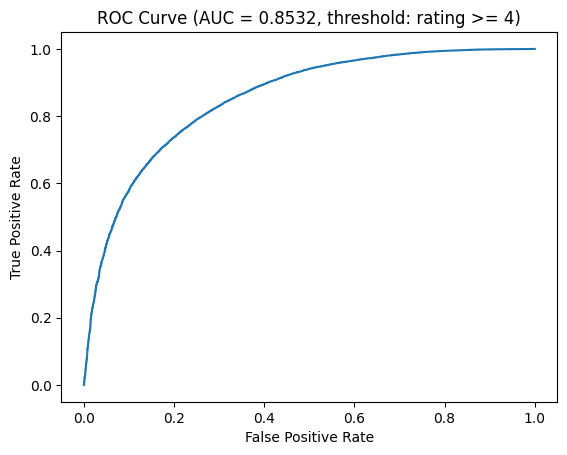

PR-AUC (Average Precision) = 0.9588144563875932


In [ ]:
# predict out_put test_df
def safe_predict(u, it):
    s = predict_score(rec_sys, u, it)
    return -1e9 if (s is None or np.isnan(s)) else float(s)

test_eval = test_df.copy()
test_eval["y_score"] = [
    safe_predict(u, it) for u, it in zip(test_eval["user_id"], test_eval["item_id"])
]

## Binarize ground-truth theo threshold rating >= 4
T = 4
test_eval["y_true"] = (test_eval["rating"] >= T).astype(int)


##  ROC-AUC (overall)
y_true = test_eval["y_true"].values
y_score = test_eval["y_score"].values
# check if 2 class
if len(np.unique(y_true)) < 2:
    raise ValueError("y_true chỉ có 1 lớp (toàn 0 hoặc toàn 1) -> không tính được ROC-AUC.")

auc = roc_auc_score(y_true, y_score)
fpr, tpr, thresholds = roc_curve(y_true, y_score)

print("ROC-AUC =", auc)

## ROC curve
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.4f}, threshold: rating >= {T})")
plt.show()

## PR-AUC nếu dữ liệu lệch lớp
pr_auc = average_precision_score(y_true, y_score)
p, r, thr = precision_recall_curve(y_true, y_score)

print("PR-AUC (Average Precision) =", pr_auc)




In [14]:
import numpy as np
from collections import defaultdict

K = 10
NEG = 100
MAX_USERS = 200
rng = np.random.default_rng(42)

# seen = tất cả item user đã tương tác (train+val+test)
user_seen = defaultdict(set)
for df in [train_df, val_df, test_df]:
    for _, r in df.iterrows():
        user_seen[r["user_id"]].add(r["item_id"])

# test items per user
user_test_items = defaultdict(list)
for _, r in test_df.iterrows():
    user_test_items[r["user_id"]].append(r["item_id"])

all_items = list(rec_sys.mappings["item2id"].keys())
all_items_set = set(all_items)

def precision_recall_ndcg_loo(ranked_items, pos_item, k=10):
    topk = ranked_items[:k]
    if pos_item not in topk:
        return 0.0, 0.0, 0.0

    rank = topk.index(pos_item)  # 0-based within topk
    hit = 1.0

    precision = hit / k          # vì chỉ có 1 positive
    recall = hit                 # |GT| = 1
    ndcg = 1.0 / np.log2(rank + 2)

    return precision, recall, ndcg

# đảm bảo eval mode
rec_sys.mcf_model.eval()
rec_sys.content_model.eval()
rec_sys.fusion_model.eval()

precisions, recalls, ndcgs = [], [], []

users = list(user_test_items.keys())[:MAX_USERS]
for u in users:
    if rec_sys.is_cold_start_user(u):
        continue

    # chọn 1 positive trong test
    pos_item = rng.choice(user_test_items[u])

    # sample negatives: item user chưa từng thấy
    pool = list(all_items_set - user_seen[u])
    if len(pool) < NEG:
        continue
    neg_items = rng.choice(pool, size=NEG, replace=False).tolist()

    candidates = [pos_item] + neg_items

    scored = []
    for it in candidates:
        s = predict_score(rec_sys, u, it)
        if s is None:
            s = -1e9
        scored.append((it, s))

    ranked = [it for it, _ in sorted(scored, key=lambda x: x[1], reverse=True)]
    p, r, n = precision_recall_ndcg_loo(ranked, pos_item, k=K)

    precisions.append(p)
    recalls.append(r)
    ndcgs.append(n)

print("Users evaluated:", len(precisions))
print(f"Precision@{K}:", float(np.mean(precisions)) if precisions else None)
print(f"Recall@{K}:",    float(np.mean(recalls))    if recalls else None)
print(f"NDCG@{K}:",      float(np.mean(ndcgs))      if ndcgs else None)


Users evaluated: 200
Precision@10: 0.0105
Recall@10: 0.105
NDCG@10: 0.04844954792457386


In [15]:
import numpy as np
import pandas as pd
from collections import defaultdict

# =========================
# CONFIG
# =========================
NEG_LIST = [50, 100, 500]     
K_LIST   = [1, 5, 10, 20]
SEEDS    = [1, 2, 3, 4, 5]
MAX_USERS = 200

# =========================
# PREP DATA
# =========================
# seen = tất cả item user đã tương tác (train+val+test)
user_seen = defaultdict(set)
for df in [train_df, val_df, test_df]:
    for _, r in df.iterrows():
        user_seen[r["user_id"]].add(r["item_id"])

# test items per user
user_test_items = defaultdict(list)
for _, r in test_df.iterrows():
    user_test_items[r["user_id"]].append(r["item_id"])

all_items = list(rec_sys.mappings["item2id"].keys())
all_items_set = set(all_items)

# đảm bảo eval mode
rec_sys.mcf_model.eval()
rec_sys.content_model.eval()
rec_sys.fusion_model.eval()

users_all = [u for u in user_test_items.keys() if not rec_sys.is_cold_start_user(u)]
users_all = users_all[:MAX_USERS]

def metrics_loo(ranked_items, pos_item, k):
    """Leave-one-out metrics with 1 positive."""
    topk = ranked_items[:k]
    if pos_item not in topk:
        return 0.0, 0.0, 0.0  # precision, recall, ndcg
    rank = topk.index(pos_item)  # 0-based within topk
    hit = 1.0
    precision = hit / k
    recall = hit
    ndcg = 1.0 / np.log2(rank + 2)
    return precision, recall, ndcg

def run_once(NEG, K, seed):
    rng = np.random.default_rng(seed)
    precisions, recalls, ndcgs = [], [], []

    for u in users_all:
        # pick 1 positive
        pos_item = rng.choice(user_test_items[u])

        # sample negatives from items user chưa từng thấy
        pool = list(all_items_set - user_seen[u])
        if len(pool) < NEG:
            continue
        neg_items = rng.choice(pool, size=NEG, replace=False).tolist()

        candidates = [pos_item] + neg_items

        scored = []
        for it in candidates:
            s = predict_score(rec_sys, u, it)
            if s is None:
                s = -1e9
            scored.append((it, s))

        ranked = [it for it, _ in sorted(scored, key=lambda x: x[1], reverse=True)]
        p, r, n = metrics_loo(ranked, pos_item, K)
        precisions.append(p)
        recalls.append(r)
        ndcgs.append(n)

    if len(recalls) == 0:
        return None

    # Random baselines for LOO with (NEG+1) candidates
    # HitRate/Recall random: K/(NEG+1)
    # Precision random: (K/(NEG+1))/K = 1/(NEG+1)
    rand_recall = K / (NEG + 1)
    rand_precision = 1 / (NEG + 1)

    # Random NDCG baseline (expected DCG): P(hit) * average(1/log2(rank+2) over ranks 0..K-1)
    discounts = np.array([1.0 / np.log2(i + 2) for i in range(K)], dtype=float)
    rand_ndcg = rand_recall * float(np.mean(discounts))

    return {
        "NEG": NEG,
        "K": K,
        "seed": seed,
        "users_evaluated": len(recalls),

        "precision": float(np.mean(precisions)),
        "recall": float(np.mean(recalls)),   # == HitRate@K
        "ndcg": float(np.mean(ndcgs)),

        "rand_precision": float(rand_precision),
        "rand_recall": float(rand_recall),
        "rand_ndcg": float(rand_ndcg),
    }

# =========================
# GRID RUN
# =========================
rows = []
for NEG in NEG_LIST:
    for K in K_LIST:
        for seed in SEEDS:
            out = run_once(NEG, K, seed)
            if out is not None:
                rows.append(out)

df = pd.DataFrame(rows)

# =========================
# AGGREGATE TABLE (mean±std over seeds)
# =========================
agg = (
    df.groupby(["NEG", "K"])
      .agg(
          users_evaluated=("users_evaluated", "min"),

          precision_mean=("precision", "mean"),
          precision_std=("precision", "std"),
          recall_mean=("recall", "mean"),
          recall_std=("recall", "std"),
          ndcg_mean=("ndcg", "mean"),
          ndcg_std=("ndcg", "std"),

          rand_precision=("rand_precision", "mean"),
          rand_recall=("rand_recall", "mean"),
          rand_ndcg=("rand_ndcg", "mean"),
      )
      .reset_index()
)

# lift vs random (mean)
agg["precision_lift"] = agg["precision_mean"] / agg["rand_precision"]
agg["recall_lift"]    = agg["recall_mean"]    / agg["rand_recall"]
agg["ndcg_lift"]      = agg["ndcg_mean"]      / agg["rand_ndcg"]

# Pretty display columns
def fmt_mean_std(m, s, digits=4):
    if pd.isna(s):
        return f"{m:.{digits}f}"
    return f"{m:.{digits}f} ± {s:.{digits}f}"

table = agg.copy()
table["Precision@K"] = table.apply(lambda r: fmt_mean_std(r["precision_mean"], r["precision_std"], 4), axis=1)
table["Recall@K"]    = table.apply(lambda r: fmt_mean_std(r["recall_mean"], r["recall_std"], 4), axis=1)
table["NDCG@K"]      = table.apply(lambda r: fmt_mean_std(r["ndcg_mean"], r["ndcg_std"], 4), axis=1)

table["Random P"] = table["rand_precision"].map(lambda x: f"{x:.4f}")
table["Random R"] = table["rand_recall"].map(lambda x: f"{x:.4f}")
table["Random N"] = table["rand_ndcg"].map(lambda x: f"{x:.4f}")

table["Lift P"] = table["precision_lift"].map(lambda x: f"{x:.2f}×")
table["Lift R"] = table["recall_lift"].map(lambda x: f"{x:.2f}×")
table["Lift N"] = table["ndcg_lift"].map(lambda x: f"{x:.2f}×")

final_cols = [
    "NEG", "K", "users_evaluated",
    "Precision@K", "Recall@K", "NDCG@K",
    "Random P", "Random R", "Random N",
    "Lift P", "Lift R", "Lift N",
]

print(table[final_cols].to_string(index=False))


 NEG  K  users_evaluated     Precision@K        Recall@K          NDCG@K Random P Random R Random N Lift P Lift R Lift N
  50  1              200 0.0220 ± 0.0091 0.0220 ± 0.0091 0.0220 ± 0.0091   0.0196   0.0196   0.0196  1.12×  1.12×  1.12×
  50  5              200 0.0224 ± 0.0018 0.1120 ± 0.0091 0.0673 ± 0.0086   0.0196   0.0980   0.0578  1.14×  1.14×  1.16×
  50 10              200 0.0191 ± 0.0007 0.1910 ± 0.0074 0.0928 ± 0.0059   0.0196   0.1961   0.0891  0.97×  0.97×  1.04×
  50 20              200 0.0200 ± 0.0009 0.4000 ± 0.0173 0.1450 ± 0.0075   0.0196   0.3922   0.1380  1.02×  1.02×  1.05×
 100  1              200 0.0160 ± 0.0082 0.0160 ± 0.0082 0.0160 ± 0.0082   0.0099   0.0099   0.0099  1.62×  1.62×  1.62×
 100  5              200 0.0126 ± 0.0015 0.0630 ± 0.0076 0.0388 ± 0.0030   0.0099   0.0495   0.0292  1.27×  1.27×  1.33×
 100 10              200 0.0120 ± 0.0008 0.1200 ± 0.0079 0.0569 ± 0.0046   0.0099   0.0990   0.0450  1.21×  1.21×  1.27×
 100 20              200 0.0094 

In [17]:
import json
# save evaluation metrics
evaluation_metrics_path = Path(config["data"]["evaluation_metrics"])
evaluation_metrics_path.mkdir(parents=True, exist_ok=True)

#csv
out_path = evaluation_metrics_path / "eval_grid_neg_k_seed.csv"
table.to_csv(out_path, index=False, encoding="utf-8-sig")
print("Saved to:", out_path)

#metadata
meta = {
    "NEG_LIST": NEG_LIST,
    "K_LIST": K_LIST,
    "SEEDS": SEEDS,
    "MAX_USERS": MAX_USERS,
    "timestamp": pd.Timestamp.now().isoformat(),
}
output_file = evaluation_metrics_path / "eval_grid_meta.json"
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

# pickle
table.to_pickle(evaluation_metrics_path / "eval_grid_summary.pkl")
df.to_pickle(evaluation_metrics_path / "eval_grid_per_seed.pkl")

# read evaluation metrics
# table = pd.read_pickle("eval_grid_summary.pkl")
# df = pd.read_pickle("eval_grid_per_seed.pkl")
# print(table[final_cols].to_string(index=False))

Saved to: data\evaluation_metrics\eval_grid_neg_k_seed.csv


### COLD_START_ITEM

In [11]:
# new item (cold start item)
new_items_df = pd.DataFrame([
    {
        "item_id": "NEW_ITEM_123",
        "category": "Headphones",
        "brand": "Sony",
        "price": 59.9,
        "title": "Wireless headphones",
        "description": "Bluetooth noise cancelling long battery"
    },
    {
        "item_id": "NEW_ITEM_456",
        "category": "Mouse",
        "brand": "Logitech",
        "price": 19.9,
        "title": "Gaming mouse",
        "description": "RGB 6 buttons ergonomic"
    }
])


In [ ]:
from pathlib import Path
from src.models.content import ContentFeatureExtractor
import pickle

# tạo extractor và load trạng thái đã fit
extractor = ContentFeatureExtractor(config)
feature_extractor_path = Path(config["data"]["processed_path"]) / "feature_extractor.pkl"
extractor.load(str(feature_extractor_path))

print("is_fitted =", extractor.is_fitted)  # phải True

# transform item mới
new_feats = extractor.transform(new_items_df)

# numpy -> torch
cat_ids = torch.tensor(new_feats["categories"], dtype=torch.long, device=device)
brand_ids = torch.tensor(new_feats["brands"], dtype=torch.long, device=device)
prices = torch.tensor(new_feats["prices"], dtype=torch.float32, device=device)
text_feat = torch.tensor(new_feats["text_features"], dtype=torch.float32, device=device)

cat_ids.shape, brand_ids.shape, prices.shape, text_feat.shape


is_fitted = True


(torch.Size([2]), torch.Size([2]), torch.Size([2, 1]), torch.Size([2, 1000]))

In [13]:
print("Unknown in category classes:", "Unknown" in extractor.category_encoder.classes_)
print("Unknown in brand classes:", "Unknown" in extractor.brand_encoder.classes_)


Unknown in category classes: True
Unknown in brand classes: True


In [14]:
# get overal score by using content_model
with torch.no_grad():
    scores = rec_sys.content_model(cat_ids, brand_ids, prices, text_feat)

scores = scores.detach().cpu().numpy()

result = new_items_df[["item_id", "category", "brand", "price"]].copy()
result["content_score_1to5"] = scores
result.sort_values("content_score_1to5", ascending=False)


,item_id,category,brand,price,content_score_1to5
1,NEW_ITEM_456,Mouse,Logitech,19.9,3.969270
0,NEW_ITEM_123,Headphones,Sony,59.9,1.018375


In [ ]:
import pandas as pd
import numpy as np

user_id = "AZ6ZOK72IVTNT"

# lấy nhiều candidates từ catalog
old_df = pd.DataFrame(rec_sys.recommend(user_id=user_id, n_items=500)).copy()
old_df["source"] = "catalog"

# item mới: dùng content score (1..5)
new_rank_df = result[["item_id"]].copy()
new_rank_df["score"] = result["content_score_1to5"].astype(float).values
new_rank_df["source"] = "cold_start_item"

# thêm cột criteria để merged không bị thiếu cột
for c in ["quality", "value", "shipping", "description"]:
    if c not in new_rank_df.columns:
        new_rank_df[c] = np.nan  # hoặc None

# gộp + ưu tiên cold_start_item nếu trùng item_id
merged = pd.concat([old_df, new_rank_df], ignore_index=True)

# ưu tiên cold_start_item nếu trùng: sort để cold nằm sau rồi drop keep last
merged["source_rank"] = merged["source"].map({"catalog": 0, "cold_start_item": 1}).fillna(0).astype(int)
merged = merged.sort_values(["item_id", "source_rank"])
merged = merged.drop_duplicates("item_id", keep="last").drop(columns=["source_rank"])

# rank chung
top10 = merged.sort_values("score", ascending=False).head(900).reset_index(drop=True)

top10


,item_id,score,quality,value,shipping,description,source
0,B00004Z6PI,4.885627,4.576054,4.495729,4.764482,4.875636,catalog
1,B000058BCO,4.836063,4.415791,4.373848,4.532991,4.690062,catalog
2,B00000J40U,4.804656,4.350086,4.294406,4.414824,4.587973,catalog
3,B000189W8M,4.802304,4.310950,4.243609,4.373162,4.581503,catalog
4,B000068O44,4.790496,4.637074,4.525210,4.934897,4.925493,catalog
...,...,...,...,...,...,...,...
497,B00004YMY5,4.611308,4.326413,4.262814,4.395747,4.595180,catalog
498,B00009329J,4.611006,4.277938,4.214801,4.302950,4.505946,catalog
499,B0001CXRXY,4.610857,4.314993,4.269515,4.390349,4.561419,catalog
500,NEW_ITEM_456,3.969270,NaN,NaN,NaN,NaN,cold_start_item
